In [4]:
# ====================================
# 1. 라이브러리 import
# ====================================
import os
import glob
import random
import shutil # 폴더 삭제, 생성 등 파일시스템 작업에 사용

# 데이터 처리 및 시각화 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 오디오 라이브러리
import librosa # 오디오 로딩
import librosa.display

# 이미지 처리 라이브러리
from PIL import Image

# 분석 라이브러리
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [15]:
# ============================================
# 2. 기본 경로 및 전역 하이퍼 파라미터 설정
# ============================================

BASE_DIR = os.getcwd() # root 디렉토리 설정 (workspace)
AUDIO_DIR = os.path.join(BASE_DIR, "audio") # 오디오 파일이 저장된 루트 폴더 지정
SPEC_DIR = os.path.join(BASE_DIR, "spectrogram_data") # 스펙트로그램으로 변환한 이미지 저장할 폴더 지정
SPLIT_DIR = os.path.join(BASE_DIR, "spectrogram_split") # 학습 데이터가 저장될 폴더 지정 (ai 학습용으로 train/test/val 구조로 저장할 예정)

# 최종 학습 모델 결과를 저장할 경로 및 파일명 지정
BEST_MODEL_PATH = os.path.join(BASE_DIR, "best_instrument_cnn_model.keras") 
#신규 예측 시 임시로 스펙트로그램 이미지를 저장할 경로 및 파일명 지정
TEMP_PREDICT_IMAGE_PATH = os.path.join(BASE_DIR, "temp_predict_spectrogram.png") 

# 분류할 클래스는 6개 (폴더명과 일치하도록 정의하기)
CLASSES = ['cello','flute','sax','oboe','trumpet','viola']

# CNN 입력 이미지 높이
IMG_HEIGHT = 224
# CNN 입력 이미지 너비
IMG_WIDTH = 224

# Signal processing 파라미터 설정 (전문가 영역/깊게 알기 전 감잡기)
# [아래 영역은 오디오 상태에 따라 최적값을 직접 잡아 주어야 한다.]
SR = 44100 # 오디오 샘플링 주파수
DURATION = 1.5 # 오디오 길이 (초단위)
SAMPLES_PER_TRACK = SR*DURATION # 1개 오디오 샘플당 기대되는 총 샘플 수
N_FFT = 2048 # 멜 스펙트로그램 생성 시 사용할 FFT 윈도우 길이 (시그널 데이터도 시계열 형식으로 들어올때 윈도우 구간으로 잘라서 분석한다. 얼마나 자를지 지정한 것이다.)
HOP_LENGTH = 1024 # 프레임 간 HOP 크기 (값이 작을수록 시간 해상도 증가)
N_MELS = 126 # MEL Filter bank (너무 작으면 정보 깨지고, 너무 크면 이미지 복잡해짐)

BATCH_SIZE = 16 # 학습 미니배치 크기
EPOCHS = 20 # 반복 학습 수

In [16]:
# ============================================
# 3. 유효성 검사 및 공통 유틸리티 함수
# ============================================

# 지정한 디렉토리가 존재하지 않으면 생성하는 함수
def ensure_directory_exists(dir_path):
    os.makedirs(dir_path, exist_ok== True)

# audio 폴더와 클래스 별 하위 폴더가 존재하는지 확인하는 함수
def validate_audio_directory_structure(audio_dir, classes):
    if not os.path.exists(audio_dir):
        raise FileNotFoundError(f"[오류] audio 루트 폴더를 찾을 수 없습니다: {audio_dir}")

    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] 클래스 폴더가 없습니다: {class_dir}")

# 클래스 별 오디오 파일 개수를 집계하여 dict 형태로 변환하는 함수
def count_audio_files(audio_dir, classes, extention="*.mp3"):
    counts = {}
    for cls in classes:
        pattern = os.path.join(audio_dir, cls, extention)
        counts[cls] = len(glob.glob(pattern))
    return counts

# 각 클래스에 최소 개수 이상의 파일이 존재하는지 검증
def validate_minimum_files_per_class(file_counts, minimum_count=3):
    for cls, count in file_counts.items():
        if count < minimum_count:
            raise ValueError(
                f"[오류] 클래스 '{cls}'의 파일 수가 너무 적습니다."
                f"최소 {minimum_count}개 이상 필요하지만 현재 {count}개 입니다."
                
            )

# 파일 또는 디렉토리가 존재할 때만 삭제
def safe_remove_path(path): 
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)

# 섹션 구분이 명확하게 보이도록 제목 출력
def print_section_title(title):
    print("\n"+("="*60))
    print(title)
    print("="*60)


데이터 폴더 및 파일 개수 확인
원본 오디오 루트 경로: C:\Users\human3_02\Desktop\programs\human-ai\workspace\audio
스펙트로그램 저장 경로: C:\Users\human3_02\Desktop\programs\human-ai\workspace\spectrogram_data
분할 데이터 저장 경로: C:\Users\human3_02\Desktop\programs\human-ai\workspace\spectrogram_split
     Class  Count
0    cello    100
1    flute    100
2      sax    100
3     oboe    100
4  trumpet    100
5    viola    100


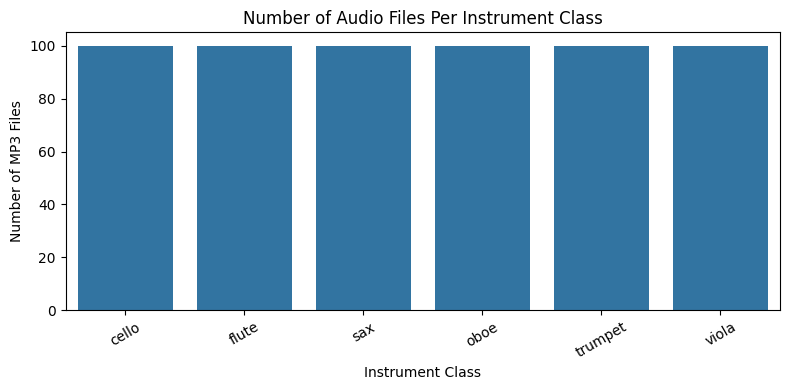

In [20]:
# ============================================
# 4. 데이터 폴더 구조 및 파일 개수 확인
# ============================================

# audio 폴더와 클래스별 하위 폴더가 실제로 존재하는지 검증
validate_audio_directory_structure(AUDIO_DIR, CLASSES)

# 클래스 별 MP3 개수 집계
file_counts = count_audio_files(AUDIO_DIR, CLASSES, extention='*.mp3')

# 각 클래스가 최소한의 샘플 수를 갖는지 확인
validate_minimum_files_per_class(file_counts, minimum_count=3)

# 집계 결과를 판다스의 데이터 프레임으로 변환
file_count_df = pd.DataFrame(list(file_counts.items()), columns=["Class","Count"])

# 현재 데이터 구성 상황을 출력
print_section_title("데이터 폴더 및 파일 개수 확인")
print("원본 오디오 루트 경로:", AUDIO_DIR)
print("스펙트로그램 저장 경로:", SPEC_DIR)
print("분할 데이터 저장 경로:", SPLIT_DIR)
print(file_count_df)

# 클래스별 데이터 불균형 여부를 matplotlib과 seaborn으로 시각화하여 확인
plt.figure(figsize=(8,4))
sns.barplot(data=file_count_df, x="Class", y="Count")
plt.title("Number of Audio Files Per Instrument Class")
plt.xlabel("Instrument Class")
plt.ylabel("Number of MP3 Files")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [34]:
# ============================================
# 5. 오디오 로드 함수 정의
# ============================================
'''
- 오디오 파일을 모노 신호로 읽고, 지정 길이로 고정하는 작업 진행
1. 모델 입력 일관성을 위해 모든 오디오 길이를 동일하게 맞춘다.
2. 너무 짧은 파일은 zero-padding 한다.
3. 너무 긴 파일은 앞부분을 사용한다.
'''

# 오디오 파일을 모노 신호로 읽고, 지정 길이로 고정하는 함수
def load_audio_file(file_path, sr=SR, duration=DURATION):
    # 입력 경로가 문자열인지 확인
    if not isinstance(file_path, str):
        raise TypeError(f"[오류] file_path는 문자열이어야 합니다. 현재 타입: {type(file_path)}")

    # 실제 파일 존재여부 확인
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"[오류] 오디오 파일이 존재하지 않습니다: {file_path}")

    # 파일 확장자 확인
    valid_exts = [".mp3",".wav",".flac",".ogg",".m4a"]
    ext = os.path.splitext(file_path)[1].lower()
    if ext not in valid_exts:
        raise ValueError(f"[오류] 지원하지 않는 오디오 확장자입니다: {ext}")

    try:
        y, sr = librosa.load(file_path, sr=sr, mono=True)
    except Exception as e:
        raise RuntimeError(f"[오류] 오디오 로드 실패: {file_path}\n원인: {e}")

    # 비어있는 배열이 들어오면 이후 FFT/STFT에서 실패하므로 사전 차단
    if y is None or len(y) == 0:
        raise ValueError(f"[오류] 오디오 데이터가 비어 있습니다: {file_path}")

    # 목표 샘플 길이 계산
    target_length = int(sr*duration)
    if len(y) < target_length:
        # 길이가 짧으면 뒤를 0으로 패딩하여 고정 길이를 맞춤
        pad_width = target_length-len(y)
        y = np.pad(y, (0, pad_width), mode="constant")
    else: 
        # 길이가 길면 앞부분만 사용
        y = y[:target_length]

    return y, sr

In [35]:
# ============================================
# 6. 샘플 오디오 파일 1개 선택 및 기본 분석
# ============================================

# 데이터 시각화 예제로 사용할 첫 번째 샘플 분석
sample_file = None
sample_class = None
for cls in CLASSES:
    pattern = os.path.join(AUDIO_DIR, cls, "*.mp3")
    files = glob.glob(pattern)
    if len(files)>0:
        sample_file = files[0]
        sample_class = cls
        break

# 샘플 파일을 하나도 찾지 못한 경우 즉시 에러 발생
if sample_file is None:
    raise FileNotFoundError("[오류] 샘플로 사용할 mp3 파일을 찾지 못했습니다.")

# 샘플 파일 로드
y_sample, sr_sample = load_audio_file(sample_file)

# 샘플 파일 정보 출력
print("샘플 클래스: ", sample_class)
print("샘플 파일: ", sample_file)
print("샘플링 주파수: ", sr_sample)
print("총 샘플 수: ", len(y_sample))
print("총 길이(초): ", len(y_sample)/sr_sample)


샘플 클래스:  cello
샘플 파일:  C:\Users\human3_02\Desktop\programs\human-ai\workspace\audio\cello\cello_A2_025_forte_arco-normal.mp3
샘플링 주파수:  44100
총 샘플 수:  66150
총 길이(초):  1.5
